<center><h1> Four-Eloop </h1></center>

In [1]:
from MCA_lib import *
import pennylane as qml

c:\Users\tosti\OneDrive\Cancel_clauses\MCA_lib.py:228: SyntaxWarning: invalid escape sequence '\o'
  labels.append(f'$\overline{{c}}_{{{rev[i]}}}$' )
c:\Users\tosti\OneDrive\Cancel_clauses\MCA_lib.py:662: SyntaxWarning: invalid escape sequence '\o'
  labels.append(f'$\overline{{c}}_{{{rev[i]}}}$' )
c:\Users\tosti\OneDrive\Cancel_clauses\MCA_lib.py:711: SyntaxWarning: invalid escape sequence '\o'
  labels.append(f'$\overline{{c}}_{{{rev[i]}}}$' )
c:\Users\tosti\OneDrive\Cancel_clauses\MCA_lib.py:743: SyntaxWarning: invalid escape sequence '\o'
  labels.append(f'$\overline{{c}}_{{{rev[i]}}}$' )


## Variables Input

In [2]:
# Número de símbolos que deseas crear
num_ext_edges=3
num_int_edges=3
num_edges =num_ext_edges+num_int_edges


num_no_reverse_clauses = 4

num_propagator_edge = [2,2,2,1,1,1]

needs_extra_qubit = False

name_diagram = 'Mercedes_opt2'

num_shots = 1000000

cut = 300

## Logical Variables

In [3]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [4]:
# Definir auxiliares

c[0] = And(S[0],S[4], Sp[3])

c[1] = And(S[1], S[5], Sp[4])

c[2] = And(S[2], S[3], Sp[5])

c[3] = And(S[0],S[1], S[2])


######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [5]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)

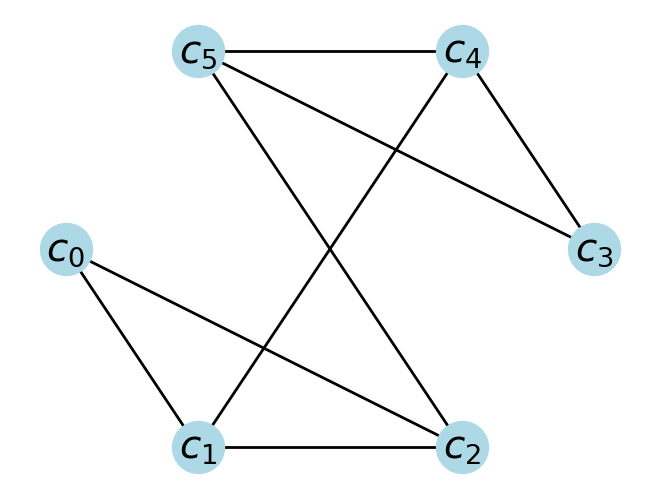

In [6]:
graph_clauses = graph_clasues(clauses, Set_edges, draw = True, name_graph = 'xmen_clauses')

In [7]:
clauses_combination = Graph_condition_combination(graph_clauses)
clauses_combination

[[1, 0, 2], [3, 4, 5]]

## Depth

In [8]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)

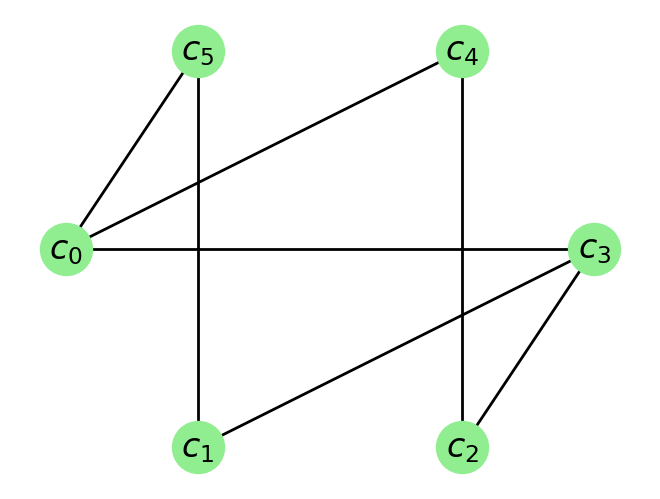

In [9]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

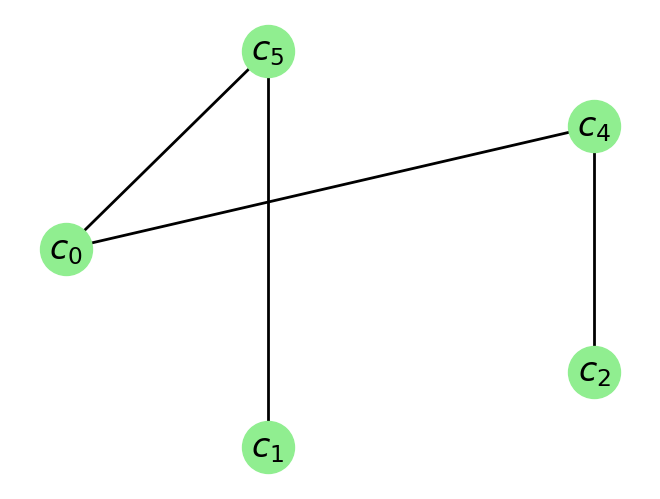

In [10]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

In [11]:
depth_combination = Graph_condition_combination(graph_depth)
depth_combination

[[0, 3], [1, 5], [2, 4]]

In [12]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges)

[[0, 3], [1, 4], [2]]


<left><h2> Qubits </h2></left>

In [13]:
# Numbers of qubits to use
num_auxs = len(clauses_combination)

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination)

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [14]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [15]:
circuit3 = circuit_function([[3], [2], [4, 0], [5, 1]])

c:\Users\tosti\anaconda3\envs\Pennylane\Lib\site-packages\pennylane\templates\broadcast.py:563: PennyLaneDeprecationWarning: qml.broadcast is deprecated and will be removed in v0.40. Please use a for loop instead
  warn(


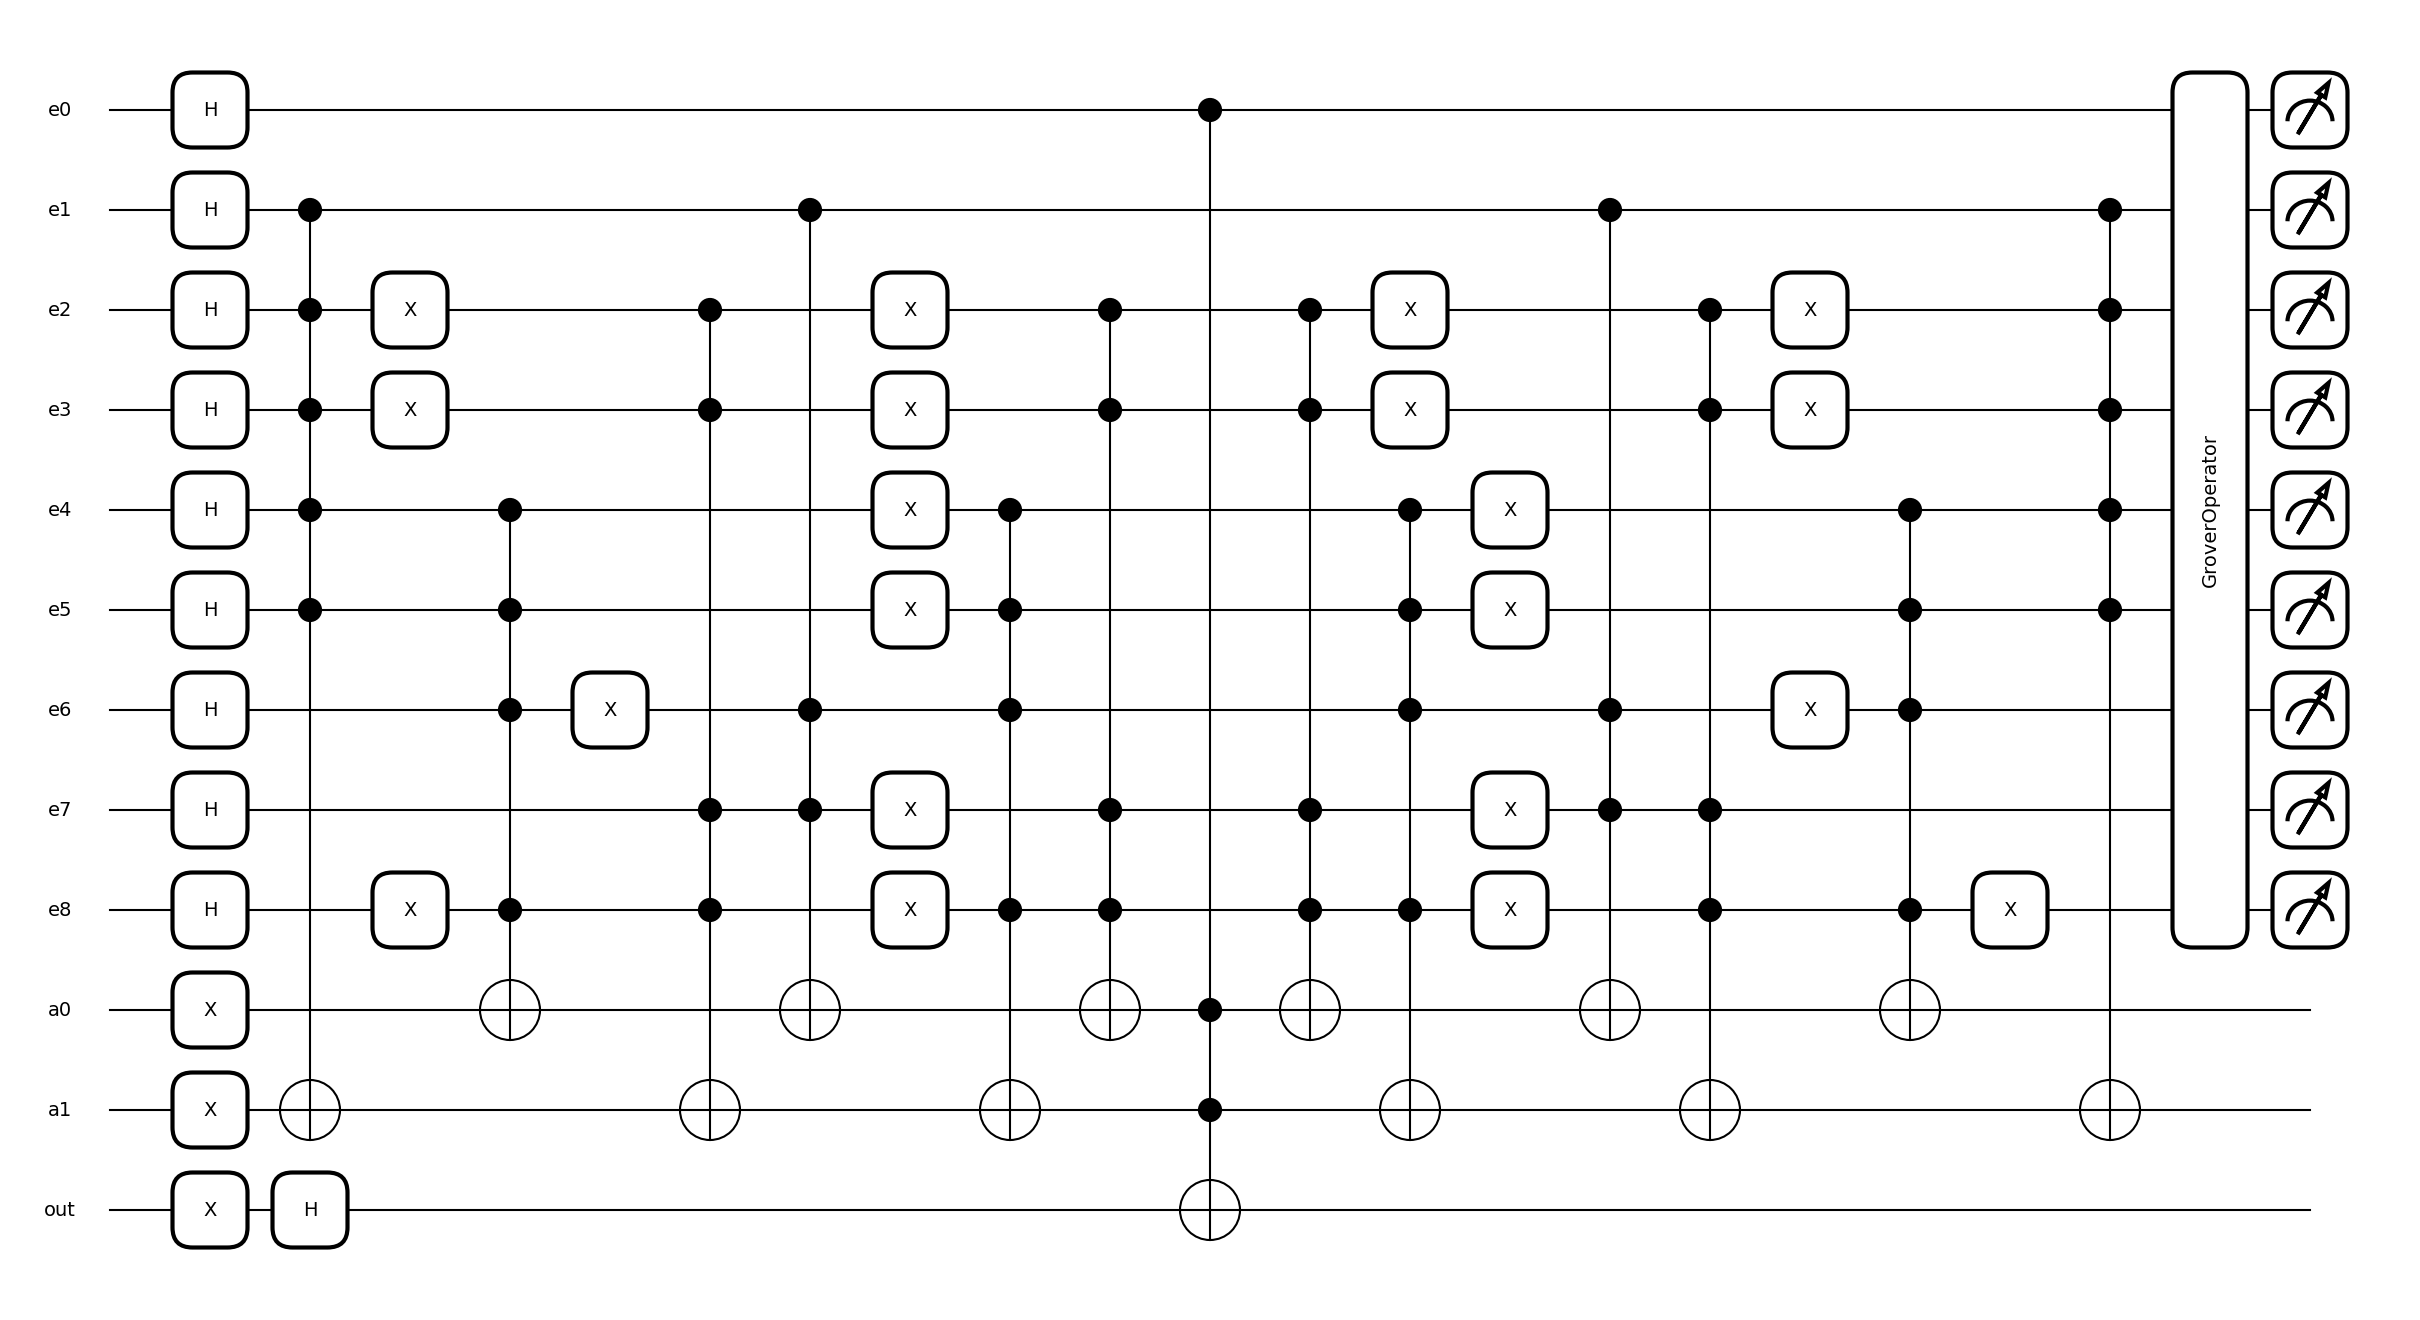

In [16]:
Draw_circuit(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [17]:
get_depth(circuit3)

The numer of depth of is: 15


c:\Users\tosti\anaconda3\envs\Pennylane\Lib\site-packages\pennylane\templates\broadcast.py:563: PennyLaneDeprecationWarning: qml.broadcast is deprecated and will be removed in v0.40. Please use a for loop instead
  warn(
c:\Users\tosti\anaconda3\envs\Pennylane\Lib\site-packages\pennylane\gradients\gradient_transform.py:265: UserWarning: Attempted to compute the gradient of a tape with no trainable parameters. If this is unintended, please mark trainable parameters in accordance with the chosen auto differentiation framework, or via the 'tape.trainable_params' property.
  warnings.warn(_no_trainable_grad_warning)


In [18]:
num_casual_states(circuit3(), cut = 300)

The number of casual states is: 170


# Optimization

## Itertools

In [19]:
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

import itertools

def generar_todas_combinaciones(subconjuntos):
    # Generar todas las permutaciones internas
    permutaciones_internas = [list(itertools.permutations(sub)) for sub in subconjuntos]

    # Producto cartesiano de las permutaciones internas
    producto_cartesiano = itertools.product(*permutaciones_internas)

    # Generar todas las permutaciones del orden de los subconjuntos
    combinaciones_finales = [
        [list(grupo) for grupo in perm]  # Convertir cada tupla interna a lista
        for combinacion in producto_cartesiano
        for perm in itertools.permutations(combinacion)
    ]

    return combinaciones_finales

# Definir el conjunto
subconjuntos = [[0, 3], [1, 5], [2, 4]]
 # Ejemplo de subconjuntos
combinaciones = generar_todas_combinaciones(subconjuntos)


results = {}
for combinacion in combinaciones: 
    results[f"{combinacion}"] = depth_circuit(combinacion)

mejor_combinacion = min(results, key=results.get)
valor_minimo = results[mejor_combinacion]

print("Mejor combinación:", mejor_combinacion)
print("Valor mínimo:", valor_minimo)

Mejor combinación: [[1, 5], [0, 3], [2, 4]]
Valor mínimo: 17


In [20]:
results

{'[[0, 3], [1, 5], [2, 4]]': 19,
 '[[0, 3], [2, 4], [1, 5]]': 19,
 '[[1, 5], [0, 3], [2, 4]]': 17,
 '[[1, 5], [2, 4], [0, 3]]': 19,
 '[[2, 4], [0, 3], [1, 5]]': 17,
 '[[2, 4], [1, 5], [0, 3]]': 19,
 '[[0, 3], [1, 5], [4, 2]]': 19,
 '[[0, 3], [4, 2], [1, 5]]': 21,
 '[[1, 5], [0, 3], [4, 2]]': 19,
 '[[1, 5], [4, 2], [0, 3]]': 21,
 '[[4, 2], [0, 3], [1, 5]]': 19,
 '[[4, 2], [1, 5], [0, 3]]': 19,
 '[[0, 3], [5, 1], [2, 4]]': 21,
 '[[0, 3], [2, 4], [5, 1]]': 19,
 '[[5, 1], [0, 3], [2, 4]]': 19,
 '[[5, 1], [2, 4], [0, 3]]': 19,
 '[[2, 4], [0, 3], [5, 1]]': 19,
 '[[2, 4], [5, 1], [0, 3]]': 21,
 '[[0, 3], [5, 1], [4, 2]]': 21,
 '[[0, 3], [4, 2], [5, 1]]': 21,
 '[[5, 1], [0, 3], [4, 2]]': 21,
 '[[5, 1], [4, 2], [0, 3]]': 21,
 '[[4, 2], [0, 3], [5, 1]]': 21,
 '[[4, 2], [5, 1], [0, 3]]': 21,
 '[[3, 0], [1, 5], [2, 4]]': 19,
 '[[3, 0], [2, 4], [1, 5]]': 19,
 '[[1, 5], [3, 0], [2, 4]]': 21,
 '[[1, 5], [2, 4], [3, 0]]': 21,
 '[[2, 4], [3, 0], [1, 5]]': 21,
 '[[2, 4], [1, 5], [3, 0]]': 21,
 '[[3, 0],

In [21]:
len(combinaciones)

48

## OPTUNA

In [22]:
import itertools
import optuna
import math

# Lista de subconjuntos base
subconjuntos_base = [[0, 3], [1, 5], [2, 4]]


# Precomputar permutaciones internas de cada subconjunto (como listas de tuplas)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputar número de permutaciones por subconjunto
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total de combinaciones internas
total_comb_internas = math.prod(num_permutaciones)

# Total de permutaciones de orden de subconjuntos
total_ordenes = math.factorial(len(subconjuntos_base))

# Total de combinaciones posibles (no generamos todas)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodificar índices internos para cada subconjunto
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Construir la combinación final
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Ejecutar la optimización
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # puedes ajustar el número de pruebas

# Mostrar el mejor resultado
mejor_idx = study.best_params["idx"]
mejor_combinacion = decodificar_combinacion(mejor_idx)
print("Mejor combinación:", mejor_combinacion)
print("Valor mínimo:", study.best_value)


c:\Users\tosti\anaconda3\envs\Pennylane\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-08 09:41:12,725] A new study created in memory with name: no-name-7a0bb701-a758-471a-bc00-4eb6158275ef
c:\Users\tosti\anaconda3\envs\Pennylane\Lib\site-packages\pennylane\templates\broadcast.py:563: PennyLaneDeprecationWarning: qml.broadcast is deprecated and will be removed in v0.40. Please use a for loop instead
  warn(
c:\Users\tosti\anaconda3\envs\Pennylane\Lib\site-packages\pennylane\gradients\gradient_transform.py:265: UserWarning: Attempted to compute the gradient of a tape with no trainable parameters. If this is unintended, please mark trainable parameters in accordance with the chosen auto differentiation framework, or via the 'tape.trainable_params' property.
  warnings.warn(_no_trainable_grad_warning)
[I 

KeyboardInterrupt: 